<a href="https://colab.research.google.com/github/SebasFru/ml-uaq/blob/main/Tarea%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

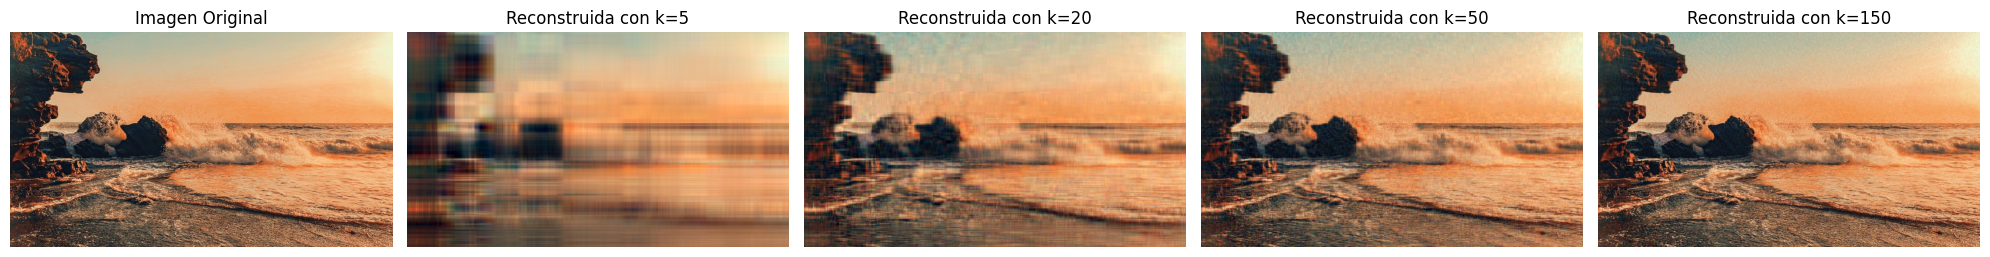

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io


nombre_archivo = 'Paisaje.jpg'
img = io.imread(nombre_archivo)

img = img.astype(float) / 255.0   #normalizar los píxeles al rango [0, 1]

if img.shape[-1] == 4:   #Para procesar PNG
    img = img[:, :, :3]

R = img[:, :, 0]   # alto, ancho, color
G = img[:, :, 1]
B = img[:, :, 2]

Ur, Sr, Vr = np.linalg.svd(R, full_matrices=False)   #ignorar ceros
Ug, Sg, Vg = np.linalg.svd(G, full_matrices=False)
Ub, Sb, Vb = np.linalg.svd(B, full_matrices=False)

def reconstruir_canal(U, S, V, k):
    return np.dot(U[:, :k], np.dot(np.diag(S[:k]), V[:k, :]))   #filas de U y k columnas

valores_k = [5, 20, 50, 150]   # cantidad de valores singulares que vamos a conservar, mayor calidad hacemos k mas grande
fig, axes = plt.subplots(1, len(valores_k) + 1, figsize=(20, 5))   #

# ima original
axes[0].imshow(img)
axes[0].set_title("Imagen Original")
axes[0].axis('off')

# Hacer y mostrar las imágenes reconstruidas
for i, k in enumerate(valores_k):
    R_k = reconstruir_canal(Ur, Sr, Vr, k)
    G_k = reconstruir_canal(Ug, Sg, Vg, k)
    B_k = reconstruir_canal(Ub, Sb, Vb, k)

    # Volvemos a apilar las 3 matrices en una sola imagen (Alto, Ancho, 3)
    img_reconstruida = np.stack((R_k, G_k, B_k), axis=2)
    img_reconstruida = np.clip(img_reconstruida, 0, 1)

    axes[i+1].imshow(img_reconstruida)
    axes[i+1].set_title(f"Reconstruida con k={k}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()